In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\ASUS\OneDrive\ドキュメント\khushi document\data.csv')
print(df.head())

   Duration          Date  Pulse  Maxpulse  Calories
0        60  '2020/12/01'    110       130     409.1
1        60  '2020/12/02'    117       145     479.0
2        60  '2020/12/03'    103       135     340.0
3        45  '2020/12/04'    109       175     282.4
4        45  '2020/12/05'    117       148     406.0


In [4]:
# Fix missing values and date format
df['Date'] = df['Date'].astype(str).str.replace("'", "").str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].ffill()

# Fill missing calories with median value
df['Calories'] = df['Calories'].fillna(df['Calories'].median())

print("Missing values handled successfully.")

Missing values handled successfully.


In [5]:
# Fix duration outliers (> 120 minutes) using median
df.loc[df['Duration'] > 120, 'Duration'] = df['Duration'].median()

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Outliers and duplicates removed successfully.")

Outliers and duplicates removed successfully.


In [7]:
# Calculate total workout duration in hours
df['Total_Workout_Hours'] = df['Duration'] / 60

#Calculate calorie burn rate per minute
df['Calories_Per_Min'] = df['Calories'] / df['Duration']

print("New columns created successfully.")

New columns created successfully.


In [8]:
# Export cleaned dataframe to a new CSV file
df.to_csv('Cleaned_Fitness_Data.csv', index=False)

print("Cleaned dataset saved as 'Cleaned_Fitness_Data.csv'")
print(df.head())

Cleaned dataset saved as 'Cleaned_Fitness_Data.csv'
   Duration       Date  Pulse  Maxpulse  Calories  Total_Workout_Hours  \
0        60 2020-12-01    110       130     409.1                 1.00   
1        60 2020-12-02    117       145     479.0                 1.00   
2        60 2020-12-03    103       135     340.0                 1.00   
3        45 2020-12-04    109       175     282.4                 0.75   
4        45 2020-12-05    117       148     406.0                 0.75   

   Calories_Per_Min  
0          6.818333  
1          7.983333  
2          5.666667  
3          6.275556  
4          9.022222  


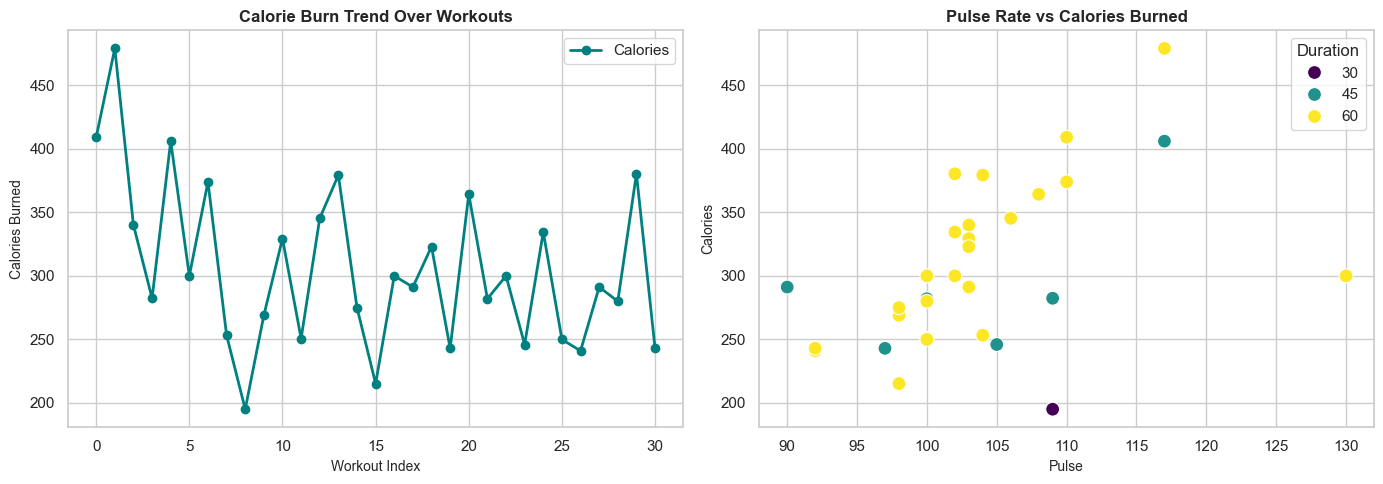

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('Cleaned_Fitness_Data.csv')

# Set Seaborn theme style
sns.set_theme(style="whitegrid")

# Create figure with custom size
plt.figure(figsize=(14, 5))

# Graph 1: Line Plot using Matplotlib (Calorie Burn Trend)
plt.subplot(1, 2, 1)
plt.plot(df.index, df['Calories'], marker='o', color='teal', linewidth=2, label='Calories')
plt.title('Calorie Burn Trend Over Workouts', fontsize=12, fontweight='bold')
plt.xlabel('Workout Index', fontsize=10)
plt.ylabel('Calories Burned', fontsize=10)
plt.legend()

# Graph 2: Scatter Plot using Seaborn (Pulse vs Calories)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Pulse', y='Calories', hue='Duration', palette='viridis', s=100)
plt.title('Pulse Rate vs Calories Burned', fontsize=12, fontweight='bold')
plt.xlabel('Pulse', fontsize=10)
plt.ylabel('Calories', fontsize=10)

# Adjust layout and display plots
plt.tight_layout()
plt.show()